In [1]:
import pandas as pd
import yfinance as yf

## Data Preparation
#Extracting and computing key financial metrics from Apple stock data (2020-2024).
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
data.head()

/Users/gayetnino/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696602,72.455920,71.472424,71.629107,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [43]:
# Extract closing price series
close = data['Close']['AAPL']

# Daily returns (% change)
rendements = close.pct_change()

# 30-day rolling volatility (standard deviation of returns)
volatilite = rendements.rolling(window=30).std()

# Portfolio simulation — 1000 CHF invested on January 1st 2020
portefeuille = 1000 * (1 + rendements).cumprod()

print(f"Average daily return: {rendements.mean() * 100:.2f}%")
print(f"Average volatility: {volatilite.mean():.4f}")
print(f"Final portfolio value: {portefeuille.iloc[-1]:.2f} CHF")

Average daily return: 0.12%
Average volatility: 0.0195
Final portfolio value: 2631.89 CHF


Output 1 — Historical Stock Price
Apple closing price from 2020 to 2024, with key market events annotated.

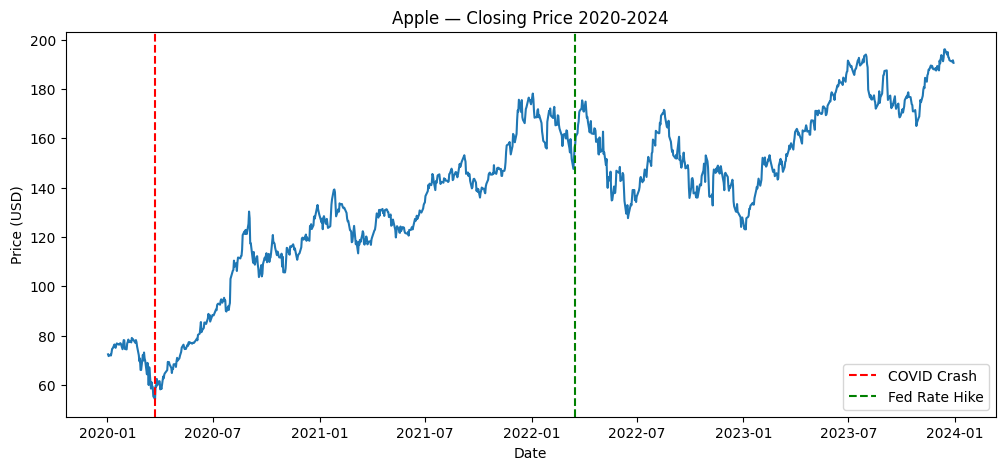

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(close)
plt.title('Apple — Closing Price 2020-2024')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.axvline(x=pd.Timestamp('2020-03-23'), color='red', linestyle='--', label='COVID Crash')
plt.axvline(x=pd.Timestamp('2022-03-16'), color='green', linestyle='--', label='Fed Rate Hike')
plt.legend()
plt.show()

Output 2 - Apple Stock volatility 2020-2024

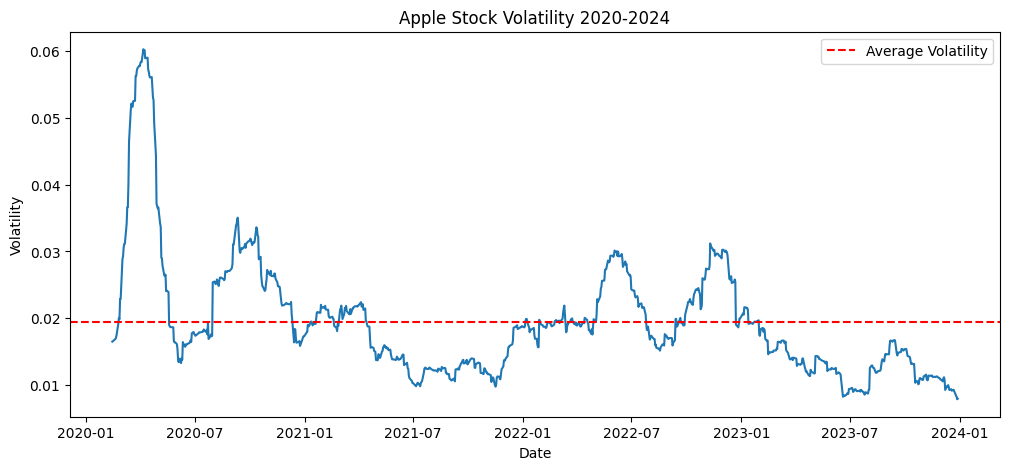

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(volatilite)
plt.title('Apple Stock Volatility 2020-2024')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.axhline(y=volatilite.mean(), color='red', linestyle='--', label='Average Volatility')
plt.legend()
plt.show()



Output 3 — Portfolio Simulation
Value of 1000 CHF invested in Apple on January 1st 2020, compounded daily.

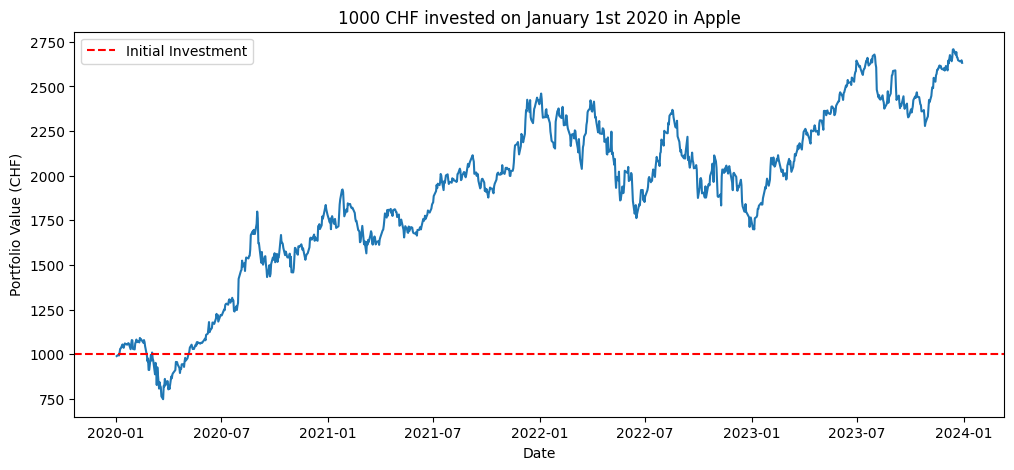

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(portefeuille)
plt.title('1000 CHF invested on January 1st 2020 in Apple')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (CHF)')
plt.axhline(y=1000, color='red', linestyle='--', label='Initial Investment')
plt.legend()
plt.show()

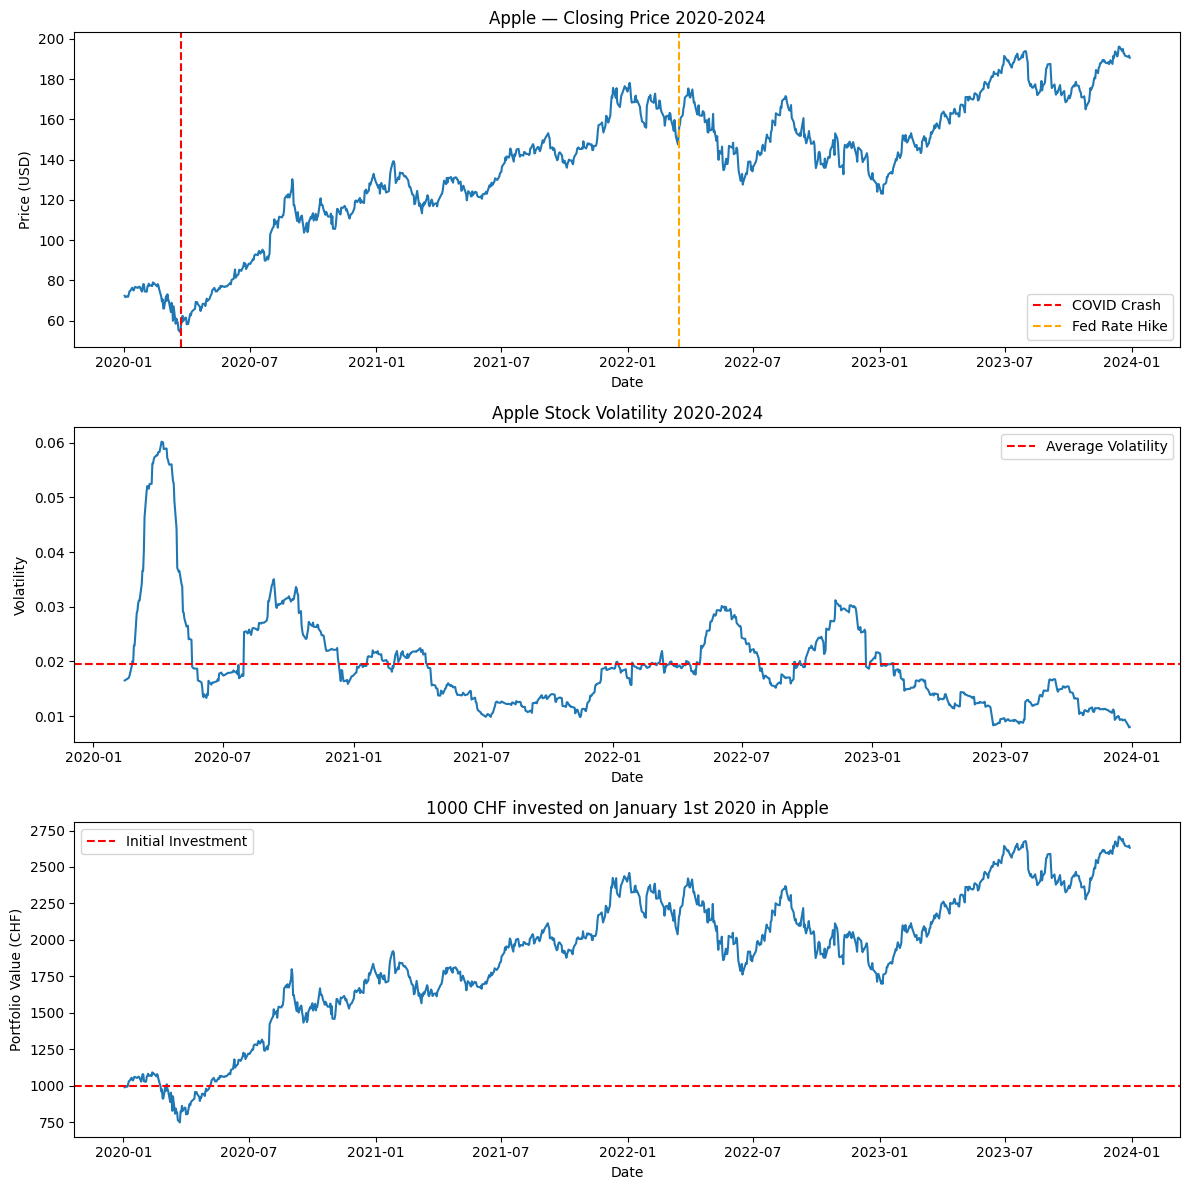

In [49]:
#Let's put all graphs together !

import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Output 1 — Historical Stock Price
ax1.plot(close)
ax1.set_title('Apple — Closing Price 2020-2024')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)')
ax1.axvline(x=pd.Timestamp('2020-03-23'), color='red', linestyle='--', label='COVID Crash')
ax1.axvline(x=pd.Timestamp('2022-03-16'), color='orange', linestyle='--', label='Fed Rate Hike')
ax1.legend()

# Output 2 — Apple Stock volatility 2020-2024
ax2.plot(volatilite)
ax2.set_title('Apple Stock Volatility 2020-2024')
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility')
ax2.axhline(y=volatilite.mean(), color='red', linestyle='--', label='Average Volatility')
ax2.legend()

# Output 3 — Portfolio Simulation
ax3.plot(portefeuille)
ax3.set_title('1000 CHF invested on January 1st 2020 in Apple')
ax3.set_xlabel('Date')
ax3.set_ylabel('Portfolio Value (CHF)')
ax3.axhline(y=1000, color='red', linestyle='--', label='Initial Investment')
ax3.legend()

plt.tight_layout()
plt.show()